In [149]:
%load_ext autoreload
%autoreload 2

from pyvtna.vtna import VTNA, order_search, order_opt, normalize_time
from pyvtna.testing import simulate_reaction_trace
import numpy as np
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Generating Dummy Data

For testing purposes, let's generate some fake data for the reaction:

$$2NO + O_2 \longrightarrow 2NO_2,  Rate=k[NO]^2[O_2]$$

We don't care about absolute rates, so we will just set k = 1

In [138]:
time = np.linspace(0, 1600, 120)
k = 0.001

# order reactants as [NO, O2]
reac_st = [2., 1.]
reac_orders = [2, 1]
reac_coefs = [2., 1.]
prod_st = [0.]
prod_coefs = [2]
noise = 0.05

[NO, O2], [NO2] = simulate_reaction_trace(time, reac_st, reac_orders, reac_coefs, 
                                           prod_st, prod_coefs, k=k, noise=noise)

## Differing Starting Concentrations
Now let's simulate a second run of the reaction, but with the starting concentration of NO doubled, as if running a series of rate experiments

In [139]:
time2 = np.linspace(0, 1400, 120)
reac_st = [3., 1.]
[NO_b, O2_b], [NO2_b] = simulate_reaction_trace(time2, reac_st, reac_orders, reac_coefs, 
                                                prod_st, prod_coefs, k=k, noise=noise)

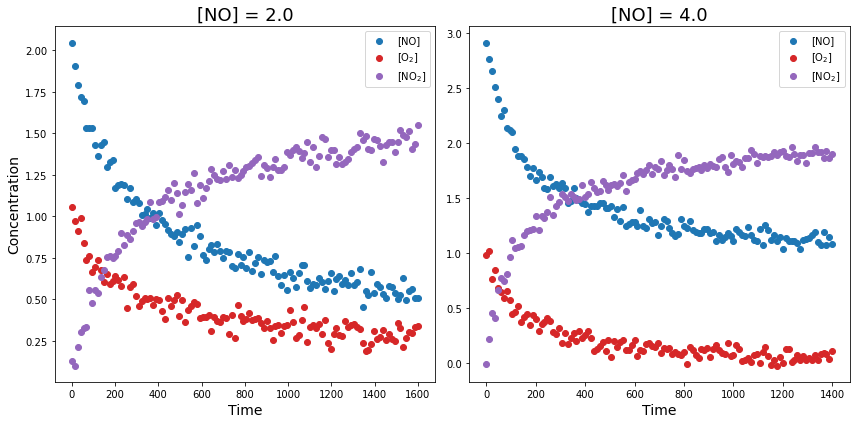

In [140]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.scatter(time, NO, c='tab:blue', label="[NO]")
ax1.scatter(time, O2, c='tab:red', label="[O$_2$]")
ax1.scatter(time, NO2, c='tab:purple', label="[NO$_2$]")
ax1.legend()
ax1.set_xlabel('Time', fontsize=14)
ax1.set_ylabel('Concentration', fontsize=14)
ax1.set_title('[NO] = 2.0', fontsize=18)

ax2.scatter(time2, NO_b, c='tab:blue', label="[NO]")
ax2.scatter(time2, O2_b, c='tab:red', label="[O$_2$]")
ax2.scatter(time2, NO2_b, c='tab:purple', label="[NO$_2$]")
ax2.legend()
ax2.set_xlabel('Time', fontsize=14)
ax2.set_title('[NO] = 4.0', fontsize=18)

plt.tight_layout()
plt.show()

## Try the Auto-Fit

Best fit achieved for an order of 2.72.


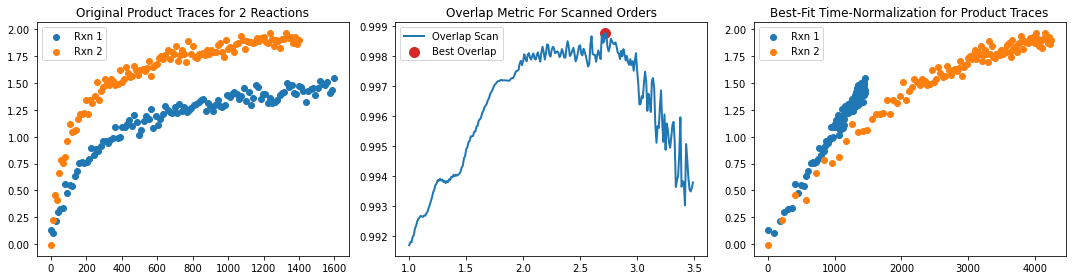

In [141]:
besto, rs = order_search(time, time2, NO2, NO2_b, NO, NO_b, o_range=(1,3.5), o_step=0.01, metric='PearR',
               to_smooth=True, win1=None, win2=None, window_type='blackman', plot=True, figsize=(15,4))

Best fit achieved for an order of 2.05.


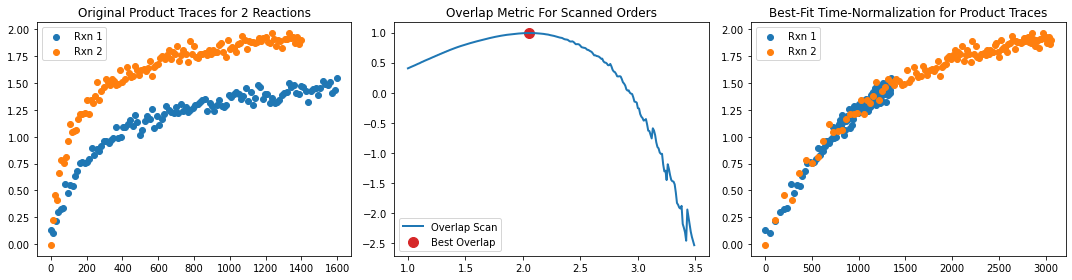

In [142]:
besto, rs = order_search(time, time2, NO2, NO2_b, NO, NO_b, o_range=(1,3.5), o_step=0.01, metric='R2',
               to_smooth=True, win1=None, win2=None, window_type='blackman', plot=True, figsize=(15,4))

Best fit achieved for an order of 2.05.


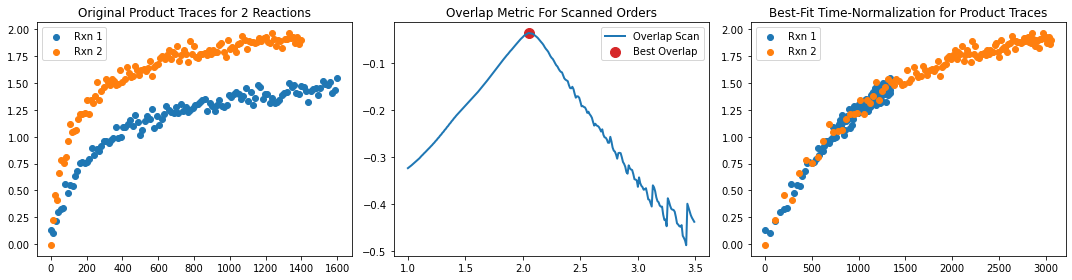

In [145]:
besto, rs = order_search(time, time2, NO2, NO2_b, NO, NO_b, o_range=(1,3.5), o_step=0.01, metric='RMSD',
               to_smooth=True, win1=None, win2=None, window_type='blackman', plot=True, figsize=(15,4))

Best fit achieved for an order of 2.06.


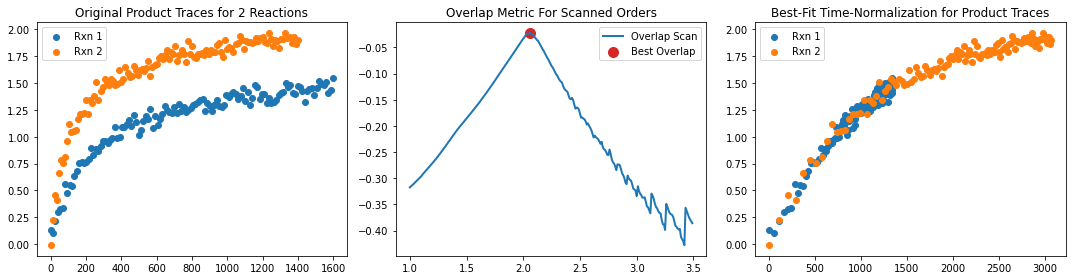

In [146]:
besto, rs = order_search(time, time2, NO2, NO2_b, NO, NO_b, o_range=(1,3.5), o_step=0.01, metric='MAD',
               to_smooth=True, win1=None, win2=None, window_type='blackman', plot=True, figsize=(15,4))

## Try The Optimization Algorithm Instead

Best fit achieved for an order of 2.05.


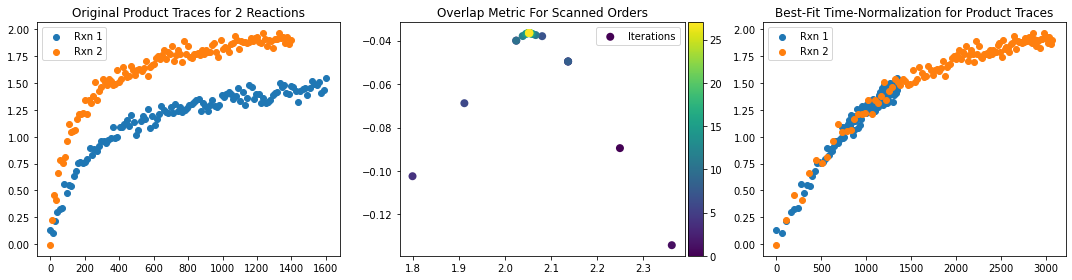

In [158]:
result, history = order_opt(time, time2, NO2, NO2_b, NO, NO_b, o_range=(1,3.5), method='Nelder-Mead', metric='RMSD',
               to_smooth=True, win1=None, win2=None, window_type='blackman', plot=True, figsize=(15,4))

## Try Auto-Fit for the Other Reactant

In [ ]:
besto, rs = order_search(time, time2, NO2, NO2_b, NO, NO_b, o_range=(1,3.5), o_step=0.01, metric='PearR',
               to_smooth=True, win1=None, win2=None, window_type='blackman', plot=True, figsize=(15,4))